In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')

In [22]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [8]:
#Data Preprocessing


In [23]:
data.shape

(7920, 3)

In [24]:
data.duplicated

<bound method DataFrame.duplicated of         id  label                                              tweet
0        1      0  #fingerprint #Pregnancy Test https://goo.gl/h1...
1        2      0  Finally a transparant silicon case ^^ Thanks t...
2        3      0  We love this! Would you go? #talk #makememorie...
3        4      0  I'm wired I know I'm George I was made that wa...
4        5      1  What amazing service! Apple won't even talk to...
...    ...    ...                                                ...
7915  7916      0  Live out loud #lol #liveoutloud #selfie #smile...
7916  7917      0  We would like to wish you an amazing day! Make...
7917  7918      0  Helping my lovely 90 year old neighbor with he...
7918  7919      0  Finally got my #smart #pocket #wifi stay conne...
7919  7920      0  Apple Barcelona!!! #Apple #Store #BCN #Barcelo...

[7920 rows x 3 columns]>

In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7915    False
7916    False
7917    False
7918    False
7919    False
Length: 7920, dtype: bool

In [27]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

###Text Preprocessing

In [28]:
import re
import string

###convert uppercase to lowercase

In [29]:
# data["tweet"] = data["tweet"].apply(lambda x : " ".joi(x.lower() for x in x.split()))


data["tweet"] = data["tweet"].apply(lambda x: " ".join(x.lower() for x in x.split()))


In [30]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

In [31]:
import nltk

In [32]:
nltk.download('stopwords', download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()

In [30]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [34]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(x for x in x.split() if x not in sw))


In [35]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally transparant silicon case ^^ thanks unc...
2    love this! would go? #talk #makememories #unpl...
3    wired know george made way ;) #iphone #cute #d...
4    amazing service! apple even talk question unle...
Name: tweet, dtype: object

#stemming

In [39]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [40]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [38]:
data

,id,label,tweet
0,1,0,#fingerprint #pregnancy test #android #apps #...
1,2,0,finally transparant silicon case ^^ thanks unc...
2,3,0,love this! would go? #talk #makememories #unpl...
3,4,0,wired know george made way ;) #iphone #cute #d...
4,5,1,amazing service! apple even talk question unle...
...,...,...,...
7915,7916,0,live loud #lol #liveoutloud #selfie #smile #so...
7916,7917,0,would like wish amazing day! make every minute...
7917,7918,0,helping lovely 90 year old neighbor ipad morni...
7918,7919,0,finally got #smart #pocket #wifi stay connecte...


#Remove Link

In [36]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*', '', x, flags=re.MULTILINE) for x in x.split()))

In [37]:
data["tweet"].head(5)

0    #fingerprint #pregnancy test  #android #apps #...
1    finally transparant silicon case ^^ thanks unc...
2    love this! would go? #talk #makememories #unpl...
3    wired know george made way ;) #iphone #cute #d...
4    amazing service! apple even talk question unle...
Name: tweet, dtype: object

#Remove puncton

In [41]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
def remove_punctuuation(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

data["tweet"] = data["tweet"].apply(remove_punctuuation)

In [43]:
data["tweet"].tail(5)

7915    live loud lol liveoutloud selfi smile soni mus...
7916    would like wish amaz day make everi minut coun...
7917    help love 90 year old neighbor ipad morn made ...
7918    final got smart pocket wifi stay connect anyti...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, dtype: object

#remove Number

In [44]:
data["tweet"] = data['tweet'].str.replace('\d+', '', regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\supun\AppData\Local\Temp\ipykernel_19320\425538495.py:1: SyntaxWarning: invalid escape sequence '\d'
  data["tweet"] = data['tweet'].str.replace('\d+', '', regex=True)


In [45]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911        complet love new iphon emojis iphon appl emoj
7912    tune in turn on drop out  gtd one app mobil mi...
7913    ok galaxi crash one day wait til monday skyroc...
7914    gain follow rt must follow follow back follow ...
7915    live loud lol liveoutloud selfi smile soni mus...
7916    would like wish amaz day make everi minut coun...
7917    help love  year old neighbor ipad morn made re...
7918    final got smart pocket wifi stay connect anyti...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, dtype: object

In [46]:
from nltk.stem import PorterStemmer
ps =PorterStemmer()

In [47]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

#Building acablary

4 ############

In [48]:
import collections 

In [49]:
from collections import Counter
vocab = Counter()

In [50]:
vocab.update(['java','python','python','c++'])

In [51]:
vocab

Counter({'python': 2, 'java': 1, 'c++': 1})

In [52]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love thi would go talk makememori unplug relax...
3,4,0,wire know georg made way iphon cute daventri home
4,5,1,amaz servic appl even talk question unless pay...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


In [53]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love thi would go talk makememori unplug relax...
3,4,0,wire know georg made way iphon cute daventri home
4,5,1,amaz servic appl even talk question unless pay...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


In [54]:
for sentence in data['tweet']:
    print(sentence)

fingerprint pregnanc test android app beauti cute health iger iphoneonli iphonesia iphon
final transpar silicon case thank uncl yay soni xperia s sonyexperias…
love thi would go talk makememori unplug relax iphon smartphon wifi connect
wire know georg made way iphon cute daventri home
amaz servic appl even talk question unless pay stupid support
iphon softwar updat fuck phone big time stupid iphon
happi us instap instadaili u soni xperia xperiaz
new type c charger cabl uk … bay amazon etsi new year rob cross tobi young evemun mcmafia taylor spectr newyear start recip technolog samsunggalaxi iphonex pictwittercompjiwqwtc
bout go shop listen music iphon justm music likeforlik followforfollow…
photo fun selfi pool water soni camera picoftheday sun instagood boy cute outdoor
hey appl make new ipod dont make new color inch thinner make crash everi five fuckin minit
ha heavi machineri need to appl realli drop ball design drinkyourhaterad
contempl give iphon bandwagon simpli cellcom new andro

In [55]:
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [56]:
len(vocab)

16019

In [57]:
vocab

Counter({'iphon': 4077,
         'appl': 2876,
         'samsung': 1395,
         'new': 1378,
         'phone': 1015,
         'follow': 885,
         'soni': 819,
         '…': 751,
         'ipad': 537,
         'rt': 525,
         'love': 499,
         'like': 455,
         'day': 426,
         'app': 416,
         'life': 415,
         'android': 414,
         'photo': 394,
         'io': 383,
         'get': 382,
         'me': 380,
         'galaxi': 361,
         'instagram': 358,
         'case': 349,
         'beauti': 323,
         'cute': 322,
         'gain': 311,
         'today': 309,
         'work': 306,
         's': 295,
         'fuck': 295,
         'happi': 294,
         'back': 294,
         'photographi': 292,
         'game': 282,
         'got': 280,
         'fun': 277,
         'thank': 263,
         'music': 263,
         'time': 248,
         'make': 247,
         'updat': 236,
         'smile': 230,
         'instagood': 226,
         'funni': 223,
      

In [58]:
len(vocab)

16019

In [59]:
data.shape

(7920, 3)

In [110]:
tokens = [key for key  in vocab if vocab[key] > 10]

In [111]:
tokens

['test',
 'android',
 'app',
 'beauti',
 'cute',
 'health',
 'iger',
 'iphoneonli',
 'iphonesia',
 'iphon',
 'final',
 'case',
 'thank',
 'yay',
 'soni',
 'xperia',
 's',
 'love',
 'thi',
 'would',
 'go',
 'talk',
 'relax',
 'smartphon',
 'wifi',
 'connect',
 'know',
 'made',
 'way',
 'home',
 'amaz',
 'servic',
 'appl',
 'even',
 'question',
 'pay',
 'stupid',
 'support',
 'softwar',
 'updat',
 'fuck',
 'phone',
 'big',
 'time',
 'happi',
 'us',
 'instap',
 'instadaili',
 'u',
 'xperiaz',
 'new',
 'type',
 'c',
 'charger',
 'cabl',
 'uk',
 '…',
 'amazon',
 'year',
 'newyear',
 'start',
 'technolog',
 'samsunggalaxi',
 'iphonex',
 'shop',
 'listen',
 'music',
 'likeforlik',
 'photo',
 'fun',
 'selfi',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'outdoor',
 'hey',
 'make',
 'ipod',
 'dont',
 'color',
 'inch',
 'crash',
 'everi',
 'need',
 'to',
 'realli',
 'drop',
 'ball',
 'design',
 'give',
 'anoth',
 'crazi',
 'purcha',
 'lol',
 'work',
 'hard',
 'play',
 'ipa

In [112]:
len(tokens)

1176

In [113]:
tokens

['test',
 'android',
 'app',
 'beauti',
 'cute',
 'health',
 'iger',
 'iphoneonli',
 'iphonesia',
 'iphon',
 'final',
 'case',
 'thank',
 'yay',
 'soni',
 'xperia',
 's',
 'love',
 'thi',
 'would',
 'go',
 'talk',
 'relax',
 'smartphon',
 'wifi',
 'connect',
 'know',
 'made',
 'way',
 'home',
 'amaz',
 'servic',
 'appl',
 'even',
 'question',
 'pay',
 'stupid',
 'support',
 'softwar',
 'updat',
 'fuck',
 'phone',
 'big',
 'time',
 'happi',
 'us',
 'instap',
 'instadaili',
 'u',
 'xperiaz',
 'new',
 'type',
 'c',
 'charger',
 'cabl',
 'uk',
 '…',
 'amazon',
 'year',
 'newyear',
 'start',
 'technolog',
 'samsunggalaxi',
 'iphonex',
 'shop',
 'listen',
 'music',
 'likeforlik',
 'photo',
 'fun',
 'selfi',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'outdoor',
 'hey',
 'make',
 'ipod',
 'dont',
 'color',
 'inch',
 'crash',
 'everi',
 'need',
 'to',
 'realli',
 'drop',
 'ball',
 'design',
 'give',
 'anoth',
 'crazi',
 'purcha',
 'lol',
 'work',
 'hard',
 'play',
 'ipa

In [114]:
def save_vocabulary(lines, filename):
    data = '/n'.join(lines)
    file = open(filename, 'w', encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vocabulary.txt')

#Divide dataset

In [65]:
x = data['tweet']
y = data['label']

In [66]:
y

0       0
1       0
2       0
3       0
4       1
       ..
7915    0
7916    0
7917    0
7918    0
7919    0
Name: label, Length: 7920, dtype: int64

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)



In [69]:
x_train.shape

(6336,)

In [70]:
x_test.shape

(1584,)

In [107]:
y_test

7577    0
41      0
1979    0
5917    0
1358    0
       ..
2676    0
955     0
365     1
5349    0
7044    0
Name: label, Length: 1584, dtype: int64

In [108]:
y_train

7250    0
4777    0
2160    1
5556    0
211     0
       ..
4287    0
998     1
7915    0
3377    0
844     0
Name: label, Length: 6336, dtype: int64

In [71]:
y_train

7250    0
4777    0
2160    1
5556    0
211     0
       ..
4287    0
998     1
7915    0
3377    0
844     0
Name: label, Length: 6336, dtype: int64

#Vectorization

In [116]:
import numpy as np  # Make sure numpy is imported

def vectorizer(ds, vocabulary):
    vectorized_lst = []
    
    for sentence in ds:
        sentence_lst = np.zeros(len(vocabulary))
        
        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence:
                sentence_lst[i] = 1
                
        vectorized_lst.append(sentence_lst)

    #vectorized_lst_new = np.arsarray(vectorized_lst, dtype=np.float32)
    vectorized_lst_new = np.asarray(vectorized_lst, dtype=np.float32)

    return vectorized_lst_new


In [117]:
vectorized_x_train = vectorizer(x_train, tokens)

In [118]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(6336, 1176), dtype=float32)

In [119]:
for i in vectorized_x_train[0]:
    print(i)


0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
1.0
0.0
1.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0


In [120]:
vectorized_x_test = vectorizer(x_test, tokens)

In [121]:
y_train

7250    0
4777    0
2160    1
5556    0
211     0
       ..
4287    0
998     1
7915    0
3377    0
844     0
Name: label, Length: 6336, dtype: int64

In [122]:
y_test

7577    0
41      0
1979    0
5917    0
1358    0
       ..
2676    0
955     0
365     1
5349    0
7044    0
Name: label, Length: 1584, dtype: int64

In [123]:
y_train.value_counts()

label
0    4706
1    1630
Name: count, dtype: int64

In [74]:
vectorizer_x_train = vectorizer(x_train, tokents)

In [75]:
vectorizer_x_train[0]

array([0., 0., 0., ..., 0., 1., 0.], shape=(1176,))

In [76]:
for i in vectorizer_x_train[0]:
    print(i)

0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
1.0
0.0
1.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0


In [77]:
vectorized_x_train = vectorizer(x_train,tokents)


In [78]:
vectorized_x_test = (x_test, tokents)

In [79]:
y_train

7250    0
4777    0
2160    1
5556    0
211     0
       ..
4287    0
998     1
7915    0
3377    0
844     0
Name: label, Length: 6336, dtype: int64

In [80]:
vectorized_x_test

(7577    respon io appl iphon iphonex losingfaith io sa...
 41      film set build timelaps video photooftheday be...
 1979    happi birthday vahid take care alway miss you ...
 5917    beauti shop aliusaexpress iphon io app new edi...
 1358    pc exquisit squishi random charm iphon strap t...
                               ...                        
 2676    number addict best iphon puzzl game ever unit ...
 955     beauti shop aliusaexpress iphon io app cat s g...
 365     appl fuck stupid pay plu tax get help phone te...
 5349    home kayrasu black blackandwhit iphon iphoneon...
 7044    got new phone christma accessori case temper g...
 Name: tweet, Length: 1584, dtype: object,
 ['test',
  'android',
  'app',
  'beauti',
  'cute',
  'health',
  'iger',
  'iphoneonli',
  'iphonesia',
  'iphon',
  'final',
  'case',
  'thank',
  'yay',
  'soni',
  'xperia',
  's',
  'love',
  'thi',
  'would',
  'go',
  'talk',
  'relax',
  'smartphon',
  'wifi',
  'connect',
  'know',
  'made',
  '

In [81]:
y_test

7577    0
41      0
1979    0
5917    0
1358    0
       ..
2676    0
955     0
365     1
5349    0
7044    0
Name: label, Length: 1584, dtype: int64

In [82]:
y_train.value_counts()

label
0    4706
1    1630
Name: count, dtype: int64

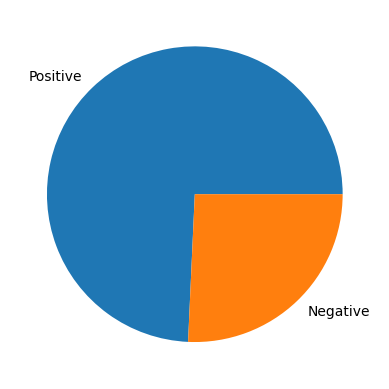

In [83]:
plt.pie(np.array([y_train.value_counts()[0], y_train.value_counts()[1]]), labels=['Positive', 'Negative'])
plt.show()

#Handle imbalanced dataset

In [124]:
from imblearn.over_sampling import SMOTE



smote = SMOTE()
vectorized_x_train_smote, y_train_smote =smote.fit_resample(vectorized_x_train, y_train)

print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9412, 1176) (9412,)


In [85]:
# Example: Vectorizing text data before applying SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# Assuming you have raw text data (e.g., X_train)
vectorizer = TfidfVectorizer(max_features=5000)
vectorized_x_train = vectorizer.fit_transform(x_train)  # This creates the vectorized feature set

# Now, apply SMOTE to balance the dataset
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)

print(vectorized_x_train_smote.shape, y_train_smote.shape)


(9412, 5000) (9412,)


In [103]:
y_train_smote

0       0
1       0
2       1
3       0
4       0
       ..
9407    1
9408    1
9409    1
9410    1
9411    1
Name: label, Length: 9412, dtype: int64

In [86]:
y_train_smote.value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       1
3       0
4       0
       ..
9407    1
9408    1
9409    1
9410    1
9411    1
Name: label, Length: 9412, dtype: int64>

In [104]:
vectorized_x_test

(7577    respon io appl iphon iphonex losingfaith io sa...
 41      film set build timelaps video photooftheday be...
 1979    happi birthday vahid take care alway miss you ...
 5917    beauti shop aliusaexpress iphon io app new edi...
 1358    pc exquisit squishi random charm iphon strap t...
                               ...                        
 2676    number addict best iphon puzzl game ever unit ...
 955     beauti shop aliusaexpress iphon io app cat s g...
 365     appl fuck stupid pay plu tax get help phone te...
 5349    home kayrasu black blackandwhit iphon iphoneon...
 7044    got new phone christma accessori case temper g...
 Name: tweet, Length: 1584, dtype: object,
 ['test',
  'android',
  'app',
  'beauti',
  'cute',
  'health',
  'iger',
  'iphoneonli',
  'iphonesia',
  'iphon',
  'final',
  'case',
  'thank',
  'yay',
  'soni',
  'xperia',
  's',
  'love',
  'thi',
  'would',
  'go',
  'talk',
  'relax',
  'smartphon',
  'wifi',
  'connect',
  'know',
  'made',
  '

In [105]:
vectorized_x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 60418 stored elements and shape (6336, 5000)>

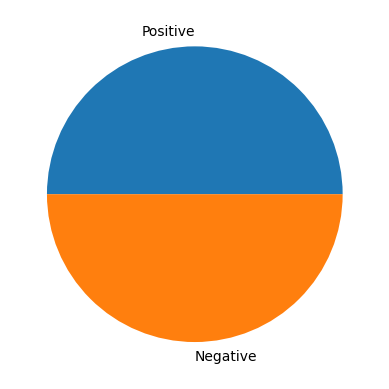

In [87]:
plt.pie(np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]), labels=['Positive', 'Negative'])
plt.show()

In [88]:
vectorized_x_train_smote

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 104103 stored elements and shape (9412, 5000)>

In [100]:
vectorized_x_test

(7577    respon io appl iphon iphonex losingfaith io sa...
 41      film set build timelaps video photooftheday be...
 1979    happi birthday vahid take care alway miss you ...
 5917    beauti shop aliusaexpress iphon io app new edi...
 1358    pc exquisit squishi random charm iphon strap t...
                               ...                        
 2676    number addict best iphon puzzl game ever unit ...
 955     beauti shop aliusaexpress iphon io app cat s g...
 365     appl fuck stupid pay plu tax get help phone te...
 5349    home kayrasu black blackandwhit iphon iphoneon...
 7044    got new phone christma accessori case temper g...
 Name: tweet, Length: 1584, dtype: object,
 ['test',
  'android',
  'app',
  'beauti',
  'cute',
  'health',
  'iger',
  'iphoneonli',
  'iphonesia',
  'iphon',
  'final',
  'case',
  'thank',
  'yay',
  'soni',
  'xperia',
  's',
  'love',
  'thi',
  'would',
  'go',
  'talk',
  'relax',
  'smartphon',
  'wifi',
  'connect',
  'know',
  'made',
  '

In [89]:
y_train_smote

0       0
1       0
2       1
3       0
4       0
       ..
9407    1
9408    1
9409    1
9410    1
9411    1
Name: label, Length: 9412, dtype: int64

In [90]:
y_test

7577    0
41      0
1979    0
5917    0
1358    0
       ..
2676    0
955     0
365     1
5349    0
7044    0
Name: label, Length: 1584, dtype: int64

##      Model Training and Evaluation

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [125]:
from sklearn.metrics import  accuracy_score, f1_score, precision_score, recall_score

def trainin_scores(y_act, y_pred): 
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Training Scores:\n\tAccuracy ={acc}\n\tPrecision = {pr}\n\tRecall ={rec}\n\tF1-Score = {f1}')


def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Testing Scores:\n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')


###Logistic Regression

In [138]:
# from sklearn.linear_model import LogisticRegression


lr= LogisticRegression()
lr.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = lr.predict(vectorized_x_train_smote)

y_test_pred = lr.predict(vectorized_x_test)

trainin_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)


Training Scores:
	Accuracy =0.948
	Precision = 0.928
	Recall =0.971
	F1-Score = 0.949
Testing Scores:
	Accuracy = 0.875
	Precision = 0.715
	Recall = 0.831
	F1-Score = 0.769


####Vaive Bayes



In [131]:
y_train_pred

array([0, 1, 1, ..., 1, 1, 1], shape=(9412,))

In [130]:
y_train_smote

0       0
1       0
2       1
3       0
4       0
       ..
9407    1
9408    1
9409    1
9410    1
9411    1
Name: label, Length: 9412, dtype: int64

In [134]:
y_test_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(1584,))

In [135]:
y_test

7577    0
41      0
1979    0
5917    0
1358    0
       ..
2676    0
955     0
365     1
5349    0
7044    0
Name: label, Length: 1584, dtype: int64

Testing Scores:
	Accuracy = 0.875
	Precision = 0.715
	Recall = 0.831
	F1-Score = 0.769


In [139]:



mnb=MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred =  mnb.predict(vectorized_x_train_smote)

y_test_pred =mnb.predict(vectorized_x_test)

trainin_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy =0.901
	Precision = 0.864
	Recall =0.952
	F1-Score = 0.906
Testing Scores:
	Accuracy = 0.863
	Precision = 0.663
	Recall = 0.919
	F1-Score = 0.77


###Decision Tree

In [141]:
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred =dt.predict(vectorized_x_train_smote)

y_test_pred =dt.predict(vectorized_x_test)

trainin_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy =1.0
	Precision = 1.0
	Recall =1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.816
	Precision = 0.632
	Recall = 0.636
	F1-Score = 0.634


#Random Forest

In [142]:
rf = RandomForestClassifier()

rf.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred = rf.predict(vectorized_x_train_smote)

y_test_pred = rf.predict(vectorized_x_test)

trainin_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy =1.0
	Precision = 1.0
	Recall =1.0
	F1-Score = 1.0
Testing Scores:
	Accuracy = 0.866
	Precision = 0.767
	Recall = 0.667
	F1-Score = 0.714


###Supoort Vector Machine

In [143]:
svm =SVC()

svm.fit(vectorized_x_train_smote, y_train_smote)

y_train_pred =  svm.predict(vectorized_x_train_smote)

y_test_pred =svm.predict(vectorized_x_test)

trainin_scores(y_train_smote, y_train_pred)

validation_scores(y_test, y_test_pred)

Training Scores:
	Accuracy =0.964
	Precision = 0.943
	Recall =0.988
	F1-Score = 0.965
Testing Scores:
	Accuracy = 0.884
	Precision = 0.742
	Recall = 0.821
	F1-Score = 0.779


In [145]:
import pickle

with open('../static/model/model.pickle', 'wb') as file:
    pickle.dump(lr, file)
